In [1]:
import pandas as pd
import glob
import os

# Input folder
data_folder = 'Data/'
csv_files = glob.glob(os.path.join(data_folder, 'Participant_*.csv'))

# Define body locations and acceleration axes
body_locations = ['Left_pocket', 'Right_pocket', 'Wrist', 'Upper_arm', 'Belt']
accel_axes = ['Ax', 'Ay', 'Az']

# List to hold all cleaned DataFrames
all_data = []

for file_path in csv_files:
    with open(file_path, 'r') as f:
        line1 = f.readline().strip().split(',')
        line2 = f.readline().strip().split(',')

    # Combine the two header rows
    header = []
    current_prefix = None
    for part1, part2 in zip(line1, line2):
        if part1:
            current_prefix = part1.strip()
        if part2:
            header.append(f"{current_prefix}_{part2.strip()}")
        else:
            header.append("")

    # Read actual data
    df = pd.read_csv(file_path, skiprows=2, header=None)
    df.columns = header

    # Extract participant ID from filename
    participant_id = int(os.path.basename(file_path).split('_')[1].split('.')[0])

    # Get activity from column index 69 (only once — it's global per row)
    if df.shape[1] > 69:
        activity_col = df.iloc[:, 69].values
    else:
        activity_col = ['unknown'] * len(df)

    # Process each position
    for loc in body_locations:
        cols = [f"{loc}_{axis}" for axis in accel_axes if f"{loc}_{axis}" in df.columns]

        if not cols:
            continue

        temp_df = df[cols].copy()
        temp_df.columns = accel_axes
        temp_df['position'] = loc
        temp_df['participant'] = participant_id
        temp_df['activity'] = activity_col

        all_data.append(temp_df)

# Combine everything
combined_df = pd.concat(all_data, ignore_index=True)

# Save
combined_df.to_csv('combined_accel_with_activity.csv', index=False)

# Print summary
print(combined_df.sample(5))
print(f"\n Total rows combined: {combined_df.shape[0]}")
print(f" Output saved as: combined_accel_with_activity.csv")




               Ax        Ay      Az      position  participant    activity
2812804 -10.20200   2.54700  1.5255          Belt            8      biking
414131    1.98860 -10.14700 -8.6081  Right_pocket           10      biking
2613007   6.97360  -0.21793 -7.0553  Right_pocket            8     sitting
1340379  -2.13840  -9.19370 -2.7513  Right_pocket            4    standing
1005962   0.88532 -16.73900 -4.8352   Left_pocket            3  downstairs

 Total rows combined: 3150000
 Output saved as: combined_accel_with_activity.csv


In [2]:
# Reading the combined data
# Load the preprocessed data
combined_df = pd.read_csv('Data/combined_accel_with_activity.csv')
combined_df.head()

,time_stamp,Ax,Ay,Az,position,participant,activity
0,1.390000e+12,-1.81150,-14.873,-1.34840,Left_pocket,1,walking
1,1.390000e+12,0.24517,-14.070,-0.84446,Left_pocket,1,walking
2,1.390000e+12,-0.57205,-14.628,-1.75700,Left_pocket,1,walking
3,1.390000e+12,-0.69464,-12.939,-3.09180,Left_pocket,1,walking
4,1.390000e+12,0.87170,-12.000,-1.56630,Left_pocket,1,walking


In [3]:
all_df_axis = combined_df[['time_stamp','Ax','Ay','Az','participant','position', 'activity']].copy()
# Convert to numpy array
all_df_axis['activity'].unique()

array(['walking', 'standing', 'jogging', 'sitting', 'biking', 'upstairs',
       'downstairs', 'upsatirs'], dtype=object)

In [4]:
all_df_axis.loc[all_df_axis['activity'] == 'upsatirs', 'activity'] = 'upstairs'
all_df_axis.sample(5)

,time_stamp,Ax,Ay,Az,participant,position,activity
2034479,1.390000e+12,2.35630,8.7987,0.66740,6,Wrist,jogging
2574704,1.390000e+12,2.49250,-15.9900,2.45170,8,Left_pocket,downstairs
313438,1.390000e+12,7.75000,-1.8387,0.92618,1,Belt,downstairs
1482381,1.390000e+12,5.70690,-6.5378,-4.84880,4,Upper_arm,sitting
2410736,1.390000e+12,0.17706,-9.3708,0.12258,7,Upper_arm,standing


In [5]:
cols_to_numeric = ['Ax', 'Ay', 'Az', 'time_stamp']
for col in cols_to_numeric:
    all_df_axis[col] = pd.to_numeric(all_df_axis[col], errors='coerce')
all_df_axis['participant'] = all_df_axis['participant'].astype('category')
all_df_axis['activity'] = all_df_axis['activity'].astype('category')

In [6]:
all_df_axis.describe()

,time_stamp,Ax,Ay,Az
count,3.150000e+06,3.150000e+06,3.150000e+06,3.150000e+06
mean,1.390000e+12,2.970175e+00,-6.286800e+00,-2.207186e+00
std,0.000000e+00,5.318678e+00,5.467467e+00,3.765335e+00
min,1.390000e+12,-1.960000e+01,-1.966800e+01,-1.949100e+01
25%,1.390000e+12,-8.172200e-02,-9.752200e+00,-4.413000e+00
50%,1.390000e+12,2.506100e+00,-7.150700e+00,-1.661700e+00
75%,1.390000e+12,6.360700e+00,-1.757000e+00,1.089600e-01
max,1.390000e+12,1.960000e+01,1.925900e+01,1.960000e+01


In [7]:
data = all_df_axis.copy()
data

,time_stamp,Ax,Ay,Az,participant,position,activity
0,1.390000e+12,-1.81150,-14.8730,-1.34840,1,Left_pocket,walking
1,1.390000e+12,0.24517,-14.0700,-0.84446,1,Left_pocket,walking
2,1.390000e+12,-0.57205,-14.6280,-1.75700,1,Left_pocket,walking
3,1.390000e+12,-0.69464,-12.9390,-3.09180,1,Left_pocket,walking
4,1.390000e+12,0.87170,-12.0000,-1.56630,1,Left_pocket,walking
...,...,...,...,...,...,...,...
3149995,1.390000e+12,9.05750,-1.9477,-1.28030,9,Belt,downstairs
3149996,1.390000e+12,9.16650,-2.1793,-1.29390,9,Belt,downstairs
3149997,1.390000e+12,10.03800,-3.2144,-1.51190,9,Belt,downstairs
3149998,1.390000e+12,9.62960,-4.2223,-1.70250,9,Belt,downstairs


In [8]:
for i in range(1, len(data['participant'].unique())+1):
    print(f'Participant {i} has {len(data[data["participant"] == i])} rows')

Participant 1 has 315000 rows
Participant 2 has 315000 rows
Participant 3 has 315000 rows
Participant 4 has 315000 rows
Participant 5 has 315000 rows
Participant 6 has 315000 rows
Participant 7 has 315000 rows
Participant 8 has 315000 rows
Participant 9 has 315000 rows
Participant 10 has 315000 rows


In [9]:
import numpy as np
data['accel_magnitude'] = np.sqrt(data['Ax']**2 + data['Ay']**2 + data['Az']**2)

In [10]:
# Check for missing values
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [11]:
import numpy as np

def replace_sensor_errors(data, threshold=1000):
    data = np.array(data, dtype=float)
    n = data.shape[0]

    # Find indices where data > threshold
    error_idx = np.where(data > threshold)[0] # to get the actual indices array from the tuple returned by np.where.

    # Handle the first element if it's an error
    if 0 in error_idx:
        valid_idx = np.where(data <= threshold)[0]
        if valid_idx.size == 0:
            raise ValueError("All values in this dataset are errors")
        data[0] = data[valid_idx[0]]

    # For the rest, replace with previous valid value
    for i in error_idx:
        if i == 0:
            continue
        data[i] = data[i-1]

    return data

# Apply only to the accel_magnitude column
data['accel_magnitude'] = replace_sensor_errors(data['accel_magnitude'].values)

In [12]:
# raw data before feature extraction and window building
data['accel_magnitude'].groupby(data['activity']).describe() 


C:\Users\garog\AppData\Local\Temp\ipykernel_29280\1947727602.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data['accel_magnitude'].groupby(data['activity']).describe()


,count,mean,std,min,25%,50%,75%,max
activity,,,,,,,,
biking,450000.0,10.039184,1.927517,0.921665,9.044184,10.000935,10.950975,30.916655
downstairs,450000.0,10.405523,4.081392,0.268638,7.641863,9.671814,12.538612,31.968675
jogging,450000.0,13.050862,6.521729,0.117166,7.620760,11.966447,19.041573,33.044148
sitting,450000.0,9.756681,0.226904,4.221222,9.652546,9.801582,9.898556,20.934715
standing,450000.0,9.871296,0.283710,3.870511,9.781635,9.890596,9.991227,18.484682
upstairs,450000.0,10.373926,3.151055,0.333906,8.327612,10.048675,12.252458,29.597370
walking,450000.0,10.676270,3.528240,0.288931,8.320685,10.398329,12.661786,31.462008


In [13]:
combined_df.sample(5) # with the other metrics
data.columns
# Group Column is like a time window of 1 second,
# we will leave it out, because we will use a sliding window of 20 seconds.


Index(['time_stamp', 'Ax', 'Ay', 'Az', 'participant', 'position', 'activity',
       'accel_magnitude'],
      dtype='object')

In [14]:
# Keep the essential columns
data_needed = data[['time_stamp','participant','activity','position','accel_magnitude']].copy()

In [15]:
# Save the cleaned and processed data to a new CSV file
output_file_path = 'Data/preprocessed_all_data.csv'
data_needed.to_csv(output_file_path, index=False)

## Creating Time Window
Info:

- window size: 20 sec
- sliding step : 1 sec = 50 Hz
- overlapping windows
- size: 1000samples = 20 seconds * 50 Hz  
- every participant has 63000 samples
- each window does

In [16]:
window_size = 1000   # 20 seconds * 50 Hz
step_size = 50       # 1 second * 50 Hz

participant_1_data = data[data['participant'] == 1].reset_index(drop=True)
windows = []

for start in range(0, len(participant_1_data) - window_size + 1, step_size):
    end = start + window_size
    window = participant_1_data.iloc[start:end]
    windows.append(window)

print(f"Total windows for participant 1: {len(windows)}")

Total windows for participant 1: 6281


# Feature Extraction
for all positions

#### Creating Time Window
Info:

- window size: 20 sec
- sliding step : 1 sec = 50 Hz
- overlapping windows
- size: 1000samples = 20 seconds * 50 Hz  
- every participant has 63000 samples
- each window does

In [17]:
import numpy as np
import pandas as pd

# Load the preprocessed data
data = pd.read_csv('Data/preprocessed_all_data.csv')
data.head()


,time_stamp,participant,activity,position,accel_magnitude
0,1.390000e+12,1,walking,Left_pocket,15.043465
1,1.390000e+12,1,walking,Left_pocket,14.097451
2,1.390000e+12,1,walking,Left_pocket,14.744242
3,1.390000e+12,1,walking,Left_pocket,13.321392
4,1.390000e+12,1,walking,Left_pocket,12.133143


### Overlapping windows with 1-second steps and 20-second window length


In [18]:
# Define window size and step size
window_size = 1000   # 20 seconds * 50 Hz
step_size = 50       # 1 second * 50 Hz

# Initialize a list to hold the windows and their corresponding majority activities
windows = []
activities = []

# Create sliding windows
for start in range(0, len(data) - window_size + 1, step_size):
    end = start + window_size
    window = data.iloc[start:end]
    windows.append(window)
    majority_activity = window['activity'].mode()[0]  # Get the majority activity
    activities.append(majority_activity)

print(f'Total windows created: {len(windows)}')

Total windows created: 62981


In [19]:
# Convert the list of windows and activities into a DataFrame
windowed_data = pd.DataFrame({'window': windows, 'majority_activity': activities})

# Display the first few entries of the windowed data
windowed_data.sample(5)

,window,majority_activity
50018,time_stamp participant activity po...,biking
29032,time_stamp participant activity ...,walking
25902,time_stamp participant activity ...,sitting
59574,time_stamp participant activity p...,jogging
30672,time_stamp participant activity po...,jogging


In [20]:
from scipy.stats import skew
from scipy.signal import welch

def extract_features(window, fs=50):
    x = window['accel_magnitude'].values.astype(float)
    features = {}
    features['mean'] = np.mean(x)
    features['std'] = np.std(x)
    features['skewness'] = skew(x)
    features['max'] = np.max(x)
    features['min'] = np.min(x)
    features['range'] = np.max(x) - np.min(x)
    # Welch's method for power spectral density
    f, Pxx = welch(x, fs=fs)
    #https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html
    
    # Μπορείς να κρατήσεις όλο το φάσμα ή π.χ. το άθροισμα ή το μέγιστο
    features['psd_sum'] = np.sum(Pxx)
    features['psd_max'] = np.max(Pxx)
    # Αν θέλεις όλο το φάσμα:
    # for i, val in enumerate(Pxx):
    #     features[f'psd_{i}'] = val
    return features

# Εξαγωγή χαρακτηριστικών για όλα τα παράθυρα
feature_list = []
for window in windows:
    feats = extract_features(window)
    feature_list.append(feats)

features_df = pd.DataFrame(feature_list)
features_df['majority_activity'] = activities
features_df.sample(5)

,mean,std,skewness,max,min,range,psd_sum,psd_max,majority_activity
41782,9.438134,0.035494,-0.120018,9.564584,9.262131,0.302453,0.006034,0.000146,standing
15259,12.441229,2.533802,-0.275429,19.251179,3.935884,15.315295,36.291300,11.207342,walking
49966,9.969956,1.570019,0.441708,17.658344,1.923640,15.734704,12.016064,0.645161,biking
25966,9.728540,1.666426,0.391516,17.840235,5.133466,12.706769,14.574357,4.156171,biking
62614,10.035078,1.370983,0.316178,15.751514,5.673577,10.077937,9.142791,0.668106,biking


In [21]:
from scipy.stats import skew
from scipy.signal import welch

def extract_features(window, fs=50):
    x = window['accel_magnitude'].values.astype(float)
    features = {}
    features['mean'] = np.mean(x)
    features['std'] = np.std(x)
    features['skewness'] = skew(x)
    features['max'] = np.max(x)
    features['min'] = np.min(x)
    features['range'] = np.max(x) - np.min(x)
    f, Pxx = welch(x, fs=fs)
    features['psd_sum'] = np.sum(Pxx)
    features['psd_max'] = np.max(Pxx)
    return features

# Helper to extract features for a given position
def extract_features_for_position(windows, activities, position_name):
    feature_list = []
    majority_activities = []
    participants = []
    positions = []
    for window, activity in zip(windows, activities):
        if window['position'].iloc[0] == position_name:
            feats = extract_features(window)
            feature_list.append(feats)
            majority_activities.append(activity)
            participants.append(window['participant'].iloc[0])
            positions.append(position_name)
    features_df = pd.DataFrame(feature_list)
    features_df['majority_activity'] = majority_activities
    features_df['participant'] = participants
    features_df['position'] = positions
    return features_df

# Create features_df for Left_pocket
features_left = extract_features_for_position(windows, activities, 'Left_pocket')
print("Left_pocket features:")
print(features_left.sample(5))

# Create features_df for Right_pocket
features_right = extract_features_for_position(windows, activities, 'Right_pocket')
print("Right_pocket features:")
print(features_right.sample(5))

Left_pocket features:
            mean       std  skewness        max       min      range  \
2293   10.777816  4.319827  0.188556  24.238000  1.239507  22.998492   
12317  10.397001  4.007272  0.634438  27.796478  1.579335  26.217143   
11030  10.768476  3.693242  0.347365  23.379159  1.883514  21.495645   
9930   11.082143  3.985282  0.679462  25.578604  3.782634  21.795970   
5450   13.769908  6.537683 -0.015183  27.531713  1.771105  25.760609   

          psd_sum    psd_max majority_activity  participant     position  
2293    91.740523  16.896755          upstairs           10  Left_pocket  
12317   87.370364  13.670854          upstairs            9  Left_pocket  
11030   72.567582  11.392901          upstairs            8  Left_pocket  
9930    88.487291  18.125859        downstairs            7  Left_pocket  
5450   218.584575  42.027204           jogging            4  Left_pocket  
Right_pocket features:
            mean       std  skewness        max       min      range  \


In [22]:
# Ensure 'participant' column exists in features_df before saving

if 'participant' not in features_df.columns:
    # Assign participant to each window based on the original data index
    # Each window is a DataFrame, so get the participant from the first row of each window
    participants = [int(window['participant'].iloc[0]) for window in windows]
    features_df['participant'] = participants

# Save the extracted features to a new CSV file
output_features_file_path = 'Data/features_all_df.csv'
features_df.to_csv(output_features_file_path, index=False)
print(f'Features DataFrame saved to {output_features_file_path}')

Features DataFrame saved to Data/features_all_df.csv


In [23]:
# Save features for Left_pocket
if 'participant' not in features_left.columns:
    participants_left = [int(window['participant'].iloc[0]) for window, activity in zip(windows, activities) if window['position'].iloc[0] == 'Left_pocket']
    features_left['participant'] = participants_left

output_features_left = 'Data/features_left_pocket.csv'
features_left.to_csv(output_features_left, index=False)
print(f'Left_pocket features saved to {output_features_left}')

# Save features for Right_pocket
if 'participant' not in features_right.columns:
    participants_right = [int(window['participant'].iloc[0]) for window, activity in zip(windows, activities) if window['position'].iloc[0] == 'Right_pocket']
    features_right['participant'] = participants_right

output_features_right = 'Data/features_right_pocket.csv'
features_right.to_csv(output_features_right, index=False)
print(f'Right_pocket features saved to {output_features_right}')

Left_pocket features saved to Data/features_left_pocket.csv
Right_pocket features saved to Data/features_right_pocket.csv


In [24]:


# Adjust the path if your features file has a different name or location
features_path = 'Data/features_all_df.csv'  # Change if needed
features_df = pd.read_csv(features_path)

In [25]:
# Ensure 'participant' and 'majority_activity' columns exist
assert 'participant' in features_df.columns, "Participant column missing!"
assert 'majority_activity' in features_df.columns, "Activity label column missing!"

participants = features_df['participant'].unique()
print(f"Participants found: {participants}")

Participants found: [ 1 10  2  3  4  5  6  7  8  9]


In [26]:
# For Left_pocket features
features_left_path = 'Data/features_left_pocket.csv'
features_left = pd.read_csv(features_left_path)
assert 'participant' in features_left.columns, "Participant column missing in left pocket features!"
assert 'majority_activity' in features_left.columns, "Activity label column missing in left pocket features!"
participants_left = features_left['participant'].unique()
print(f"Participants in Left_pocket: {participants_left}")

# For Right_pocket features
features_right_path = 'Data/features_right_pocket.csv'
features_right = pd.read_csv(features_right_path)
assert 'participant' in features_right.columns, "Participant column missing in right pocket features!"
assert 'majority_activity' in features_right.columns, "Activity label column missing in right pocket features!"
participants_right = features_right['participant'].unique()
print(f"Participants in Right_pocket: {participants_right}")

Participants in Left_pocket: [ 1 10  2  3  4  5  6  7  8  9]
Participants in Right_pocket: [ 1 10  2  3  4  5  6  7  8  9]


#### Question 5 (train on left pocket, test on right)


##### last tasks 

- last grid searches for the best model
- change the test set according to the question 5 and use the best model
- combination of labels for better confusion matrix
-  report
- presentation




(the simplest svm model Mean LOSO SVM Accuracy: 0.658 for all data took 30minutes...... so decide the best of all and just one try)

In [27]:
## question 5
# --- Training the best model: LOSO Cross-Validation Loop with Fixed Random Forest Parameters ---
# Having as training set the data of each participant on position 'Left_pocket'
# and using the position 'Right_pocket' for testing

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Fixed parameters as specified
rf_params = {
    'n_estimators': 150,
    'max_depth': 10,
    'min_samples_split': 5,
    'max_features': 'sqrt',
    'criterion': 'entropy',
    'random_state': 28
}

results = []
feature_importances = []
all_y_true = []
all_y_pred = []

for pid in participants:
    train_df = features_df[features_df['participant'] != pid]
    test_df = features_df[features_df['participant'] == pid]
    
    X_train = train_df.drop(['majority_activity', 'participant'], axis=1)
    y_train = train_df['majority_activity']
    X_test = test_df.drop(['majority_activity', 'participant'], axis=1)
    y_test = test_df['majority_activity']
    
    clf = RandomForestClassifier(**rf_params)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    # Collect for confusion matrix
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    results.append({'participant': pid, 'accuracy': acc, 'report': report})
    feature_importances.append(clf.feature_importances_)
    
    print(f"Participant {pid} - Accuracy: {acc:.3f}")

mean_acc = np.mean([r['accuracy'] for r in results])
print(f"\nMean LOSO Accuracy: {mean_acc:.3f}")

Participant 1 - Accuracy: 0.752
Participant 10 - Accuracy: 0.630
Participant 2 - Accuracy: 0.783
Participant 3 - Accuracy: 0.675
Participant 4 - Accuracy: 0.754
Participant 5 - Accuracy: 0.690
Participant 6 - Accuracy: 0.770
Participant 7 - Accuracy: 0.825
Participant 8 - Accuracy: 0.728
Participant 9 - Accuracy: 0.744

Mean LOSO Accuracy: 0.735


In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      biking       0.83      0.98      0.90       181
  downstairs       0.95      0.88      0.91       181
     jogging       0.99      1.00      1.00       181
     sitting       0.67      0.01      0.02       179
    standing       0.50      0.98      0.66       180
    upstairs       0.95      0.89      0.92       179
     walking       0.99      0.94      0.97       179

    accuracy                           0.81      1260
   macro avg       0.84      0.81      0.77      1260
weighted avg       0.84      0.81      0.77      1260



## the best selected model -> random forest & SVM 



In [28]:
features_df

,mean,std,skewness,max,min,range,psd_sum,psd_max,majority_activity,participant
0,11.736444,5.091533,0.543480,30.089941,1.427759,28.662182,132.902476,20.655853,walking,1
1,11.782961,5.057029,0.534450,30.089941,1.955204,28.134737,130.908283,20.761550,walking,1
2,11.766262,5.028216,0.524125,30.089941,1.955204,28.134737,129.099252,20.517201,walking,1
3,11.740971,5.020599,0.538271,30.089941,1.955204,28.134737,130.038679,20.773804,walking,1
4,11.706259,5.005546,0.534554,29.460821,1.955204,27.505617,126.983161,20.958660,walking,1
...,...,...,...,...,...,...,...,...,...,...
62976,10.215077,3.275768,0.994558,22.444263,3.408828,19.035435,53.857715,9.682182,downstairs,9
62977,10.227290,3.290707,1.016160,22.444263,3.408828,19.035435,51.723084,10.219452,downstairs,9
62978,10.234265,3.234348,1.056303,22.444263,3.635627,18.808636,53.713649,11.491836,downstairs,9
62979,10.210648,3.126067,1.033960,22.444263,3.635627,18.808636,54.325164,11.720255,downstairs,9


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import pandas as pd

# Load features for left and right pockets
features_left = pd.read_csv('Data/features_left_pocket.csv')
features_right = pd.read_csv('Data/features_right_pocket.csv')

participants = features_left['participant'].unique()

rf_params = {
    'n_estimators': 100,
    'max_depth': 10,
    'min_samples_split': 5,
    'max_features': 'sqrt',
    'criterion': 'entropy',
    'random_state': 28
}

results = []
feature_importances = []
all_y_true = []
all_y_pred = []

for pid in participants:
    train_df = features_left[features_left['participant'] == pid]
    test_df = features_right[features_right['participant'] == pid]
    
    if train_df.empty or test_df.empty:
        print(f"Skipping participant {pid}: insufficient data for Left_pocket or Right_pocket.")
        continue
    
    X_train = train_df.drop(['majority_activity', 'participant', 'position'], axis=1)
    y_train = train_df['majority_activity']
    X_test = test_df.drop(['majority_activity', 'participant', 'position'], axis=1)
    y_test = test_df['majority_activity']
    
    clf = RandomForestClassifier(**rf_params)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    results.append({'participant': pid, 'accuracy': acc, 'report': report})
    feature_importances.append(clf.feature_importances_)
    
    print(f"Participant {pid} - Accuracy: {acc:.3f}")

mean_acc = np.mean([r['accuracy'] for r in results])
print(f"\nMean LOSO Accuracy: {mean_acc:.3f}")
print(classification_report(y_test,y_pred))

Participant 1 - Accuracy: 0.825
Participant 10 - Accuracy: 0.643
Participant 2 - Accuracy: 0.926
Participant 3 - Accuracy: 0.884
Participant 4 - Accuracy: 0.617
Participant 5 - Accuracy: 0.715
Participant 6 - Accuracy: 0.955
Participant 7 - Accuracy: 0.623
Participant 8 - Accuracy: 0.869
Participant 9 - Accuracy: 0.763

Mean LOSO Accuracy: 0.782
              precision    recall  f1-score   support

      biking       0.82      0.84      0.83       181
  downstairs       0.94      0.66      0.78       181
     jogging       1.00      0.99      0.99       181
     sitting       0.08      0.01      0.02       179
    standing       0.51      0.99      0.67       180
    upstairs       0.83      0.89      0.86       179
     walking       0.86      0.95      0.90       179

    accuracy                           0.76      1260
   macro avg       0.72      0.76      0.72      1260
weighted avg       0.72      0.76      0.72      1260



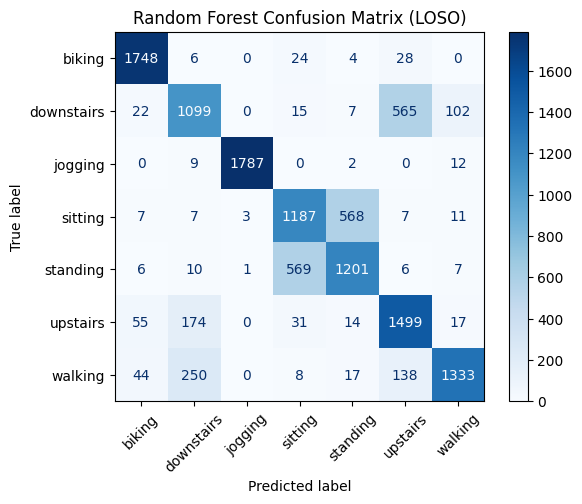

In [30]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
class_names = sorted(features_df['majority_activity'].unique())  
cm = confusion_matrix(all_y_true, all_y_pred, labels=class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix (LOSO)")
plt.xticks(rotation=45)
plt.show()

### SVM other position

In [6]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Load features for left and right pockets
features_left = pd.read_csv('Data/features_left_pocket.csv')
features_right = pd.read_csv('Data/features_right_pocket.csv')

participants = features_left['participant'].unique()

svm_params = {'C': 0.1, 'gamma': 0.125,'degree': 2, 'kernel': 'poly'}

results = []
all_y_true = []
all_y_pred = []

for pid in participants:
    train_df = features_left[features_left['participant'] == pid]
    test_df = features_right[features_right['participant'] == pid]
    
    if train_df.empty or test_df.empty:
        print(f"Skipping participant {pid}: insufficient data for Left_pocket or Right_pocket.")
        continue
    
    X_train = train_df.drop(['majority_activity', 'participant', 'position'], axis=1)
    y_train = train_df['majority_activity']
    X_test = test_df.drop(['majority_activity', 'participant', 'position'], axis=1)
    y_test = test_df['majority_activity']
    
    clf = SVC(**svm_params, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    results.append({'participant': pid, 'accuracy': acc, 'report': report})
    
    print(f"Participant {pid} - Accuracy: {acc:.3f}")

mean_acc = np.mean([r['accuracy'] for r in results])
print(f"\nMean LOSO SVM Accuracy (Left→Right): {mean_acc:.3f}")
print(classification_report(y_test,y_pred))


Participant 1 - Accuracy: 0.709
Participant 10 - Accuracy: 0.625
Participant 2 - Accuracy: 0.815
Participant 3 - Accuracy: 0.769
Participant 4 - Accuracy: 0.711
Participant 5 - Accuracy: 0.727
Participant 6 - Accuracy: 0.835
Participant 7 - Accuracy: 0.545
Participant 8 - Accuracy: 0.727
Participant 9 - Accuracy: 0.812

Mean LOSO SVM Accuracy (Left→Right): 0.728
              precision    recall  f1-score   support

      biking       0.82      0.98      0.89       181
  downstairs       0.93      0.90      0.91       181
     jogging       0.99      1.00      1.00       181
     sitting       1.00      0.01      0.01       179
    standing       0.50      0.99      0.66       180
    upstairs       0.96      0.87      0.91       179
     walking       0.99      0.94      0.97       179

    accuracy                           0.81      1260
   macro avg       0.89      0.81      0.77      1260
weighted avg       0.89      0.81      0.77      1260



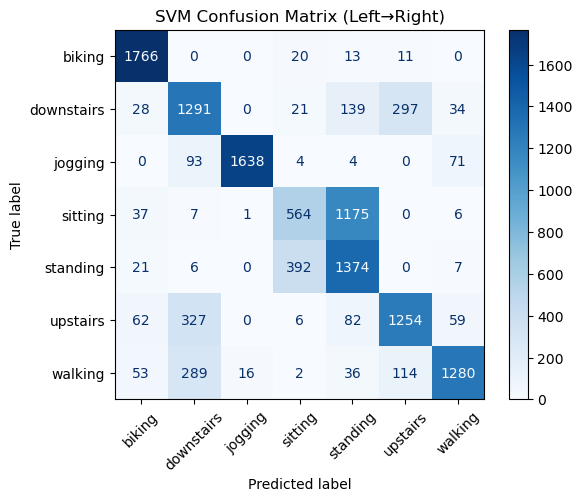

In [8]:
# Plot confusion matrix
import matplotlib.pyplot as plt
class_names = sorted(list(set(all_y_true) | set(all_y_pred)))
cm = confusion_matrix(all_y_true, all_y_pred, labels=class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("SVM Confusion Matrix (Left→Right)")
plt.xticks(rotation=45)
plt.show()